In [1]:
# 📈 Momentum & Mean-Reversion Strategy Notebook
## Setup
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ta


In [2]:
## 1. Load Historical Data
symbol = "TSLA"
df = yf.download(symbol, start="2020-01-01", end="2025-05-01")
df = df.dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
df.columns = df.columns.get_level_values(-2)

In [4]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,28.684000,28.713333,28.114000,28.299999,142981500
2020-01-03,29.534000,30.266666,29.128000,29.366667,266677500
2020-01-06,30.102667,30.104000,29.333332,29.364668,151995000
2020-01-07,31.270666,31.441999,30.224001,30.760000,268231500
2020-01-08,32.809334,33.232666,31.215334,31.580000,467164500
...,...,...,...,...,...
2025-04-24,259.510010,259.540009,249.199997,250.500000,94464200
2025-04-25,284.950012,286.850006,259.630005,261.690002,167560700
2025-04-28,285.880005,294.859985,272.420013,288.980011,151731800


In [5]:

## 2. Add Indicators
# Momentum: RSI
rsi = ta.momentum.RSIIndicator(close=df['Close'], window=14)
df['RSI'] = rsi.rsi()

# Mean Reversion: Bollinger Bands
bb = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_High'] = bb.bollinger_hband()
df['BB_Low'] = bb.bollinger_lband()

In [6]:
## 3. Strategy Rules
df['Signal'] = 0

# Momentum Buy: RSI crosses above 50
df.loc[(df['RSI'] > 50) & (df['RSI'].shift(1) <= 50), 'Signal'] = 1

# Mean-Reversion Buy: Close crosses below lower BB
df.loc[(df['Close'] < df['BB_Low']) & (df['Close'].shift(1) >= df['BB_Low'].shift(1)), 'Signal'] = 1

# Sell if RSI drops below 50 or crosses upper BB
df.loc[(df['RSI'] < 50) | (df['Close'] > df['BB_High']), 'Signal'] = -1

In [7]:
## 4. Backtest
capital = 10000
position = 0
df['Portfolio'] = np.nan

for i in range(1, len(df)):
    if df.loc[df.index[i], 'Signal'] == 1 and position == 0:
        position = capital / df.loc[df.index[i], 'Close']
        capital = 0
    elif df.loc[df.index[i], 'Signal'] == -1 and position > 0:
        capital = position * df.loc[df.index[i], 'Close']
        position = 0
    df.loc[df.index[i], 'Portfolio'] = capital + position * df.loc[df.index[i], 'Close']

# Fill remaining NaNs with last value
df['Portfolio'].fillna(method='ffill', inplace=True)

C:\Users\rponn\AppData\Local\Temp\ipykernel_7312\490612373.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Portfolio'].fillna(method='ffill', inplace=True)
C:\Users\rponn\AppData\Local\Temp\ipykernel_7312\490612373.py:16: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Portfolio'].fillna(method='ffill', inplace=True)


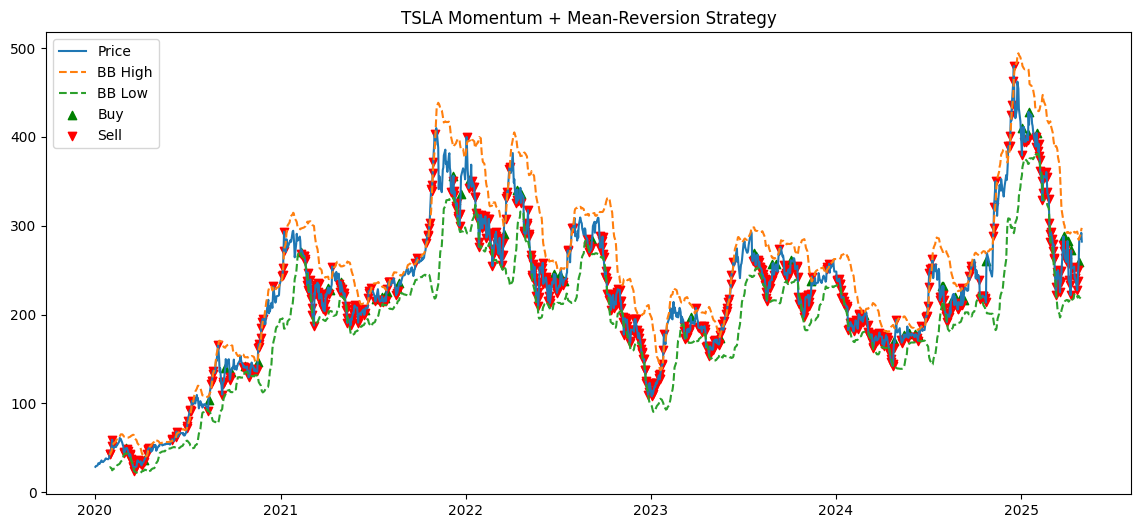

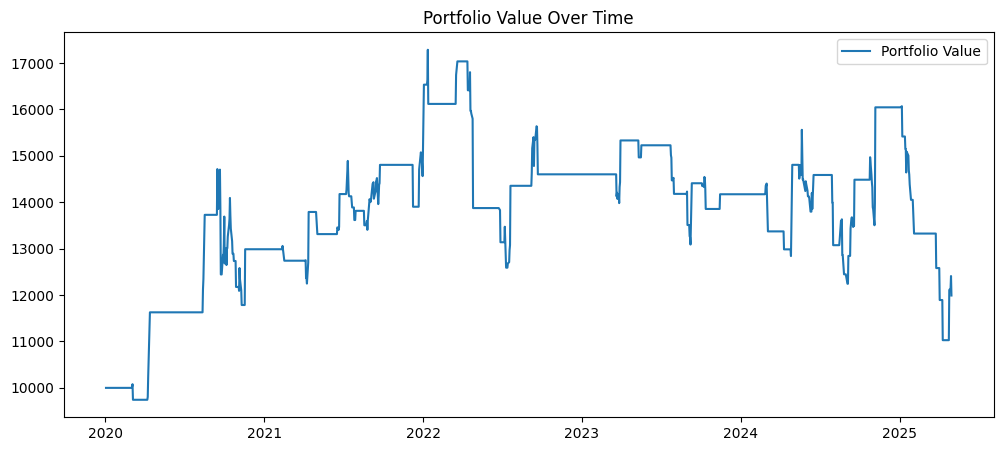

In [8]:
## 5. Visualize
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Close'], label='Price')
plt.plot(df.index, df['BB_High'], linestyle='--', label='BB High')
plt.plot(df.index, df['BB_Low'], linestyle='--', label='BB Low')
plt.scatter(df[df['Signal'] == 1].index, df[df['Signal'] == 1]['Close'], marker='^', color='g', label='Buy')
plt.scatter(df[df['Signal'] == -1].index, df[df['Signal'] == -1]['Close'], marker='v', color='r', label='Sell')
plt.legend()
plt.title(f'{symbol} Momentum + Mean-Reversion Strategy')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df['Portfolio'], label='Portfolio Value')
plt.title('Portfolio Value Over Time')
plt.legend()
plt.show()

In [9]:
## 6. Summary Metrics
returns = df['Portfolio'].pct_change().dropna()
sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252)
drawdown = (df['Portfolio'] / df['Portfolio'].cummax()) - 1
max_drawdown = drawdown.min()

In [10]:
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

Sharpe Ratio: 0.26
Max Drawdown: -36.20%
